In [21]:
# %pip install torch
from transformers import pipeline
from nltk import sent_tokenize
import nltk
import torch
from glob import glob
import pandas as pd
import numpy as np

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/keshtech/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# Load Model

In [3]:
model_name = "facebook/bart-large-mnli"
#device = 0 if torch.cuda.is_available() else "cpu"
device = 'cpu'

In [4]:
device

'cpu'

In [5]:
def load_model(device):
    theme_classifier = pipeline(
        "zero-shot-classification",
        model=model_name,
        device=device)
    
    return theme_classifier

In [7]:
theme_classifier = load_model(device)

In [8]:
theme_list = ["friendship","hope","sacrifice","battle","self development","betrayal","love","dialogue"]

In [9]:
theme_classifier(
    "I gave him a right hook then a left jab",
    theme_list,
    multi_label=True
)

{'sequence': 'I gave him a right hook then a left jab',
 'labels': ['battle',
  'self development',
  'hope',
  'sacrifice',
  'dialogue',
  'betrayal',
  'love',
  'friendship'],
 'scores': [0.9121253490447998,
  0.47500181198120117,
  0.08781816065311432,
  0.04500045254826546,
  0.020132921636104584,
  0.012040478177368641,
  0.0042923795990645885,
  0.002817221451550722]}

# Load Dataset

In [12]:
files = glob('../data/Subtitles/*.ass')

In [13]:
files[:5]

['../data/Subtitles/Naruto Season 5 - 118.ass',
 '../data/Subtitles/Naruto Season 5 - 112.ass',
 '../data/Subtitles/Naruto Season 1 - 24.ass',
 '../data/Subtitles/Naruto Season 6 - 148.ass',
 '../data/Subtitles/Naruto Season 5 - 123.ass']

In [14]:
with open(files[0],'r') as file:
    lines = file.readlines()
    lines = lines[27:]
    lines =  [ ",".join(line.split(',')[9:])  for line in lines ]

In [15]:
lines[:2]

['Connecting old words\\Nthat have been used up\n',
 'I just want to convey\\Nmy simple thoughts\n']

In [16]:
lines = [ line.replace('\\N',' ') for line in lines]

In [17]:
lines[:2]

['Connecting old words that have been used up\n',
 'I just want to convey my simple thoughts\n']

In [18]:
" ".join(lines[:10])

"Connecting old words that have been used up\n I just want to convey my simple thoughts\n That day's faint wind blows away\n at the castle ruins of yesterday\n I'll laugh with you and live for the moment\n Still that incident will continue to trouble you, right?\n That's why it must be good-bye\n Leaving nothing behind, let us share what is left\n In time, we'll realize that it was everything\n And sadness will touch our cheeks, creating a river of tears\n"

In [19]:
int(files[0].split('-')[-1].split('.')[0].strip())

118

In [22]:
def load_subtitles_dataset(dataset_path):
    subtitles_paths = glob(dataset_path+'/*.ass')

    scripts=[]
    episode_num=[]

    for path in subtitles_paths:

        #Read Lines
        with open(path,'r') as file:
            lines = file.readlines()
            lines = lines[27:]
            lines =  [ ",".join(line.split(',')[9:])  for line in lines ]
        
        lines = [ line.replace('\\N',' ') for line in lines]
        script = " ".join(lines)

        episode = int(path.split('-')[-1].split('.')[0].strip())

        scripts.append(script)
        episode_num.append(episode)

    df = pd.DataFrame.from_dict({"episode":episode_num, "script":scripts })
    return df

In [23]:
dataset_path = "../data/Subtitles"
df = load_subtitles_dataset(dataset_path)

In [24]:
df.head()

,episode,script
0,118,Connecting old words that have been used up\n ...
1,112,Connecting old words that have been used up\n ...
2,24,"C'mon!\n Running like a fugitive,\n Being chas..."
3,148,"Hey boys, listen up!\n Humans aren’t such a bi..."
4,123,Connecting old words that have been used up\n ...


Run Model

In [25]:
script = df.iloc[0]['script']

In [26]:
script

"Connecting old words that have been used up\n I just want to convey my simple thoughts\n That day's faint wind blows away\n at the castle ruins of yesterday\n I'll laugh with you and live for the moment\n Still that incident will continue to trouble you, right?\n That's why it must be good-bye\n Leaving nothing behind, let us share what is left\n In time, we'll realize that it was everything\n And sadness will touch our cheeks, creating a river of tears\n Trembling thoughts swept into a vortex and melting away\n Hurry!\n Right…\n We’re close!\n There are two enemies left…\n There are three of us… lt’s three against two.\n We might be able to do it with one more contact if we do it well.\n All right! All right! Let’s do it!\n No! It’s four against two!\n Okay, okay! I’m sorry.\n Counting Akamaru, it’s four against two!\n Let’s finish it quickly with our new technique next!\n Say, say. If necessary, I’ll do an awesome Shadow Clone,\n so it’ll be okay!\n That’s reassuring…\n But my strat

In [27]:
script_sentences = sent_tokenize(script)
script_sentences[:3]

["Connecting old words that have been used up\n I just want to convey my simple thoughts\n That day's faint wind blows away\n at the castle ruins of yesterday\n I'll laugh with you and live for the moment\n Still that incident will continue to trouble you, right?",
 "That's why it must be good-bye\n Leaving nothing behind, let us share what is left\n In time, we'll realize that it was everything\n And sadness will touch our cheeks, creating a river of tears\n Trembling thoughts swept into a vortex and melting away\n Hurry!",
 'Right…\n We’re close!']

In [28]:
# Batch Sentence
sentence_batch_size=20
script_batches = []
for index in range(0,len(script_sentences),sentence_batch_size):
    sent = " ".join(script_sentences[index:index+sentence_batch_size])
    script_batches.append(sent)

In [29]:
script_batches[:2]

["Connecting old words that have been used up\n I just want to convey my simple thoughts\n That day's faint wind blows away\n at the castle ruins of yesterday\n I'll laugh with you and live for the moment\n Still that incident will continue to trouble you, right? That's why it must be good-bye\n Leaving nothing behind, let us share what is left\n In time, we'll realize that it was everything\n And sadness will touch our cheeks, creating a river of tears\n Trembling thoughts swept into a vortex and melting away\n Hurry! Right…\n We’re close! There are two enemies left…\n There are three of us… lt’s three against two. We might be able to do it with one more contact if we do it well. All right! All right! Let’s do it! No! It’s four against two! Okay, okay! I’m sorry. Counting Akamaru, it’s four against two! Let’s finish it quickly with our new technique next! Say, say. If necessary, I’ll do an awesome Shadow Clone,\n so it’ll be okay! That’s reassuring…\n But my strategy comes first. Got 

In [30]:
theme_output = theme_classifier(
    script_batches[:2],
    theme_list,
    multi_label=True
)

In [31]:
theme_output

[{'sequence': "Connecting old words that have been used up\n I just want to convey my simple thoughts\n That day's faint wind blows away\n at the castle ruins of yesterday\n I'll laugh with you and live for the moment\n Still that incident will continue to trouble you, right? That's why it must be good-bye\n Leaving nothing behind, let us share what is left\n In time, we'll realize that it was everything\n And sadness will touch our cheeks, creating a river of tears\n Trembling thoughts swept into a vortex and melting away\n Hurry! Right…\n We’re close! There are two enemies left…\n There are three of us… lt’s three against two. We might be able to do it with one more contact if we do it well. All right! All right! Let’s do it! No! It’s four against two! Okay, okay! I’m sorry. Counting Akamaru, it’s four against two! Let’s finish it quickly with our new technique next! Say, say. If necessary, I’ll do an awesome Shadow Clone,\n so it’ll be okay! That’s reassuring…\n But my strategy come

In [32]:
# Wrangle Ouput
# battle: [0.51489498, 0.2156498] Score for battle for each batch of sentences. The first score is the probability of the theme being present, and the second score is the probability of the theme not being present.
themes = {}
for output in theme_output:
    for label,score in zip(output['labels'],output['scores']):
        if label not in themes:
            themes[label] = []
        themes[label].append(score)

In [33]:
themes

{'battle': [0.9357759952545166, 0.933498203754425],
 'sacrifice': [0.8783913254737854, 0.8728908896446228],
 'dialogue': [0.8271288871765137, 0.9378595948219299],
 'self development': [0.7023184895515442, 0.7598146200180054],
 'friendship': [0.6923350691795349, 0.3017074763774872],
 'betrayal': [0.4356963038444519, 0.5571909546852112],
 'hope': [0.4095730185508728, 0.4031667113304138],
 'love': [0.30729568004608154, 0.07160237431526184]}

In [34]:
themes = {key: np.mean(np.array(value)) for key,value in themes.items()}

In [35]:
themes

{'battle': 0.9346370995044708,
 'sacrifice': 0.8756411075592041,
 'dialogue': 0.8824942409992218,
 'self development': 0.7310665547847748,
 'friendship': 0.49702127277851105,
 'betrayal': 0.49644362926483154,
 'hope': 0.4063698649406433,
 'love': 0.1894490271806717}

In [36]:
def get_themes_inference(script):
    script_sentences = sent_tokenize(script)

    # Batch Sentence
    sentence_batch_size=20
    script_batches = []
    for index in range(0,len(script_sentences),sentence_batch_size):
        sent = " ".join(script_sentences[index:index+sentence_batch_size])
        script_batches.append(sent)
    
    # Run Model
    theme_output = theme_classifier(
        script_batches[:2],
        theme_list,
        multi_label=True
    )

    # Wrangle Output 
    themes = {}
    for output in theme_output:
        for label,score in zip(output['labels'],output['scores']):
            if label not in themes:
                themes[label] = []
            themes[label].append(score)

    themes = {key: np.mean(np.array(value)) for key,value in themes.items()}

    return themes

In [37]:
df = df.head(2)

In [38]:
df

,episode,script
0,118,Connecting old words that have been used up\n ...
1,112,Connecting old words that have been used up\n ...


In [39]:
output_themes = df['script'].apply(get_themes_inference)

In [40]:
theme_df = pd.DataFrame(output_themes.tolist())

In [41]:
theme_df

,battle,sacrifice,dialogue,self development,friendship,betrayal,hope,love
0,0.934637,0.875641,0.882494,0.731067,0.497021,0.496444,0.406370,0.189449
1,0.691901,0.666082,0.881444,0.747392,0.551133,0.504832,0.666219,0.207489


In [42]:
df[theme_df.columns] = theme_df
df

,episode,script,battle,sacrifice,dialogue,self development,friendship,betrayal,hope,love
0,118,Connecting old words that have been used up\n ...,0.934637,0.875641,0.882494,0.731067,0.497021,0.496444,0.406370,0.189449
1,112,Connecting old words that have been used up\n ...,0.691901,0.666082,0.881444,0.747392,0.551133,0.504832,0.666219,0.207489


# Visualize Output

In [43]:
df = df.drop('dialogue',axis=1)

In [44]:
df

,episode,script,battle,sacrifice,self development,friendship,betrayal,hope,love
0,118,Connecting old words that have been used up\n ...,0.934637,0.875641,0.731067,0.497021,0.496444,0.406370,0.189449
1,112,Connecting old words that have been used up\n ...,0.691901,0.666082,0.747392,0.551133,0.504832,0.666219,0.207489


In [45]:
theme_output = df.drop(['episode','script'],axis=1).sum().reset_index()
theme_output.columns = ['theme','score']
theme_output

,theme,score
0,battle,1.626538
1,sacrifice,1.541723
2,self development,1.478459
3,friendship,1.048154
4,betrayal,1.001276
5,hope,1.072589
6,love,0.396938


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

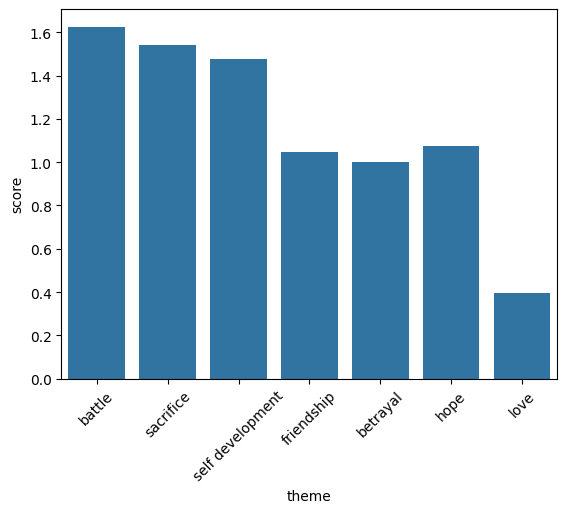

In [47]:
sns.barplot(data = theme_output ,x="theme",y="score" )
plt.xticks(rotation=45)
plt.show()